In [12]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import roc_auc_score, mean_absolute_error
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt

In [25]:
data = pd.read_csv('D:/my_ML/diploma_polytech/data/raw/vehicle_ins_data_1.csv', sep = ";",index_col= False)

# Создание целевой переменной: 1 если N_claims_year > 1, иначе 0
data['claim_prob'] = (data['N_claims_year'] > 1).astype(int)

# Предобработка данных
# Удаление ненужных столбцов, но НЕ УДАЛЯЕМ Date_start_contract
cols_to_drop = ['ID','Date_last_renewal', 'Date_next_renewal', 
                'Date_lapse', 'N_claims_year', 'Cost_claims_year', 'N_claims_history', 
                'R_Claims_history']
data = data.drop(columns=cols_to_drop)

# Преобразуем Date_start_contract в datetime ДО любой обработки
data['Date_start_contract'] = pd.to_datetime(data['Date_start_contract'], errors='coerce')#pd.to_datetime(data['Date_start_contract'], errors='coerce')

C:\Users\andre\AppData\Local\Temp\ipykernel_22560\1910749945.py:1: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('D:/my_ML/diploma_polytech/data/raw/vehicle_ins_data_1.csv', sep = ";",index_col= False)


In [16]:
# 1. Сначала обработать ВСЕ датовые колонки, если они существуют
date_columns = ['Date_birth', 'Date_driving_licence']

# Создаем список существующих датовых колонок
existing_date_columns = [col for col in date_columns if col in data.columns]

# Проверим, какие датовые колонки нашлись
print("Существующие датовые колонки для обработки:", existing_date_columns)

if not existing_date_columns:
    print("Предупреждение: Датовые колонки не найдены в DataFrame.")
else:
    for col in existing_date_columns:
        data[col] = pd.to_datetime(data[col], format='%d/%m/%Y', errors='coerce')

    # 2. Извлечь числовые признаки из существующих дат
    reference_date = pd.to_datetime('2019-12-31')
    
    if 'Date_birth' in data.columns:
        data['Age'] = (reference_date - data['Date_birth']).dt.days // 365
    
    if 'Date_driving_licence' in data.columns:
        data['Driving_experience'] = (reference_date - data['Date_driving_licence']).dt.days // 365

    

# 2. Извлечь числовые признаки из дат
reference_date = pd.to_datetime('2019-12-31')
data['Age'] = (reference_date - data['Date_birth']).dt.days // 365
data['Driving_experience'] = (reference_date - data['Date_driving_licence']).dt.days // 365

# 3. Удалить исходные датовые колонки
data = data.drop(columns=date_columns)
data = data.drop(columns=existing_date_columns, errors='ignore')
# 4. Обработать категориальные переменные
categorical_cols = ['Type_fuel']
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col].astype(str))
    label_encoders[col] = le

# 5. Убедиться, что все данные числовые
data = data.apply(pd.to_numeric, errors='coerce')

# 6. Обработка пропущенных значений
imputer = SimpleImputer(strategy='median')
data_imputed = imputer.fit_transform(data)
data = pd.DataFrame(data_imputed, columns=data.columns)

Существующие датовые колонки для обработки: ['Date_birth', 'Date_driving_licence']


In [17]:
# Разделение на признаки и целевую переменную
X = data.drop(columns=['claim_prob'])
y = data['claim_prob']

# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Масштабирование признаков
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Преобразование в тензоры PyTorch
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)
# Разделение по дате
# train_mask = data['Date_start_contract'] < '2017-07-01'
# X_train = data[train_mask].drop(columns=['claim_prob', 'Date_start_contract'])
# y_train = data[train_mask]['claim_prob']
# X_test = data[~train_mask].drop(columns=['claim_prob', 'Date_start_contract'])
# y_test = data[~train_mask]['claim_prob']

# # Масштабирование признаков
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

# # Преобразование в тензоры PyTorch
# X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
# y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
# X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
# y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

In [18]:
# Создание нейронной сети
class InsuranceNet(nn.Module):
    def __init__(self, input_size):
        super(InsuranceNet, self).__init__()
        self.layer1 = nn.Linear(input_size, 72)
        self.layer2 = nn.Linear(72, 64)
        self.layer3 = nn.Linear(64, 48)
        self.layer4 = nn.Linear(48, 36)
        self.layer5 = nn.Linear(36, 24)
        #self.layer6 = nn.Linear(36, 24)
        self.output = nn.Linear(24,1)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        x = self.relu(self.layer3(x))
        x = self.relu(self.layer4(x))
        x = self.relu(self.layer5(x))
        #x = self.relu(self.layer6(x))
        x = self.sigmoid(self.output(x))
        return x

# Инициализация модели
input_size = X_train_tensor.shape[1]
print(input_size)
model = InsuranceNet(input_size)

# Определение функции потерь и оптимизатора
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)



22


In [19]:
# Обучение модели
epochs = 350
losses =[]
epochs_plt =[]
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    loss.backward()
    optimizer.step()
    
    if (epoch+1) % 10 == 0:
        losses.append(loss.item())
        epochs_plt.append(epoch+1)
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')


Epoch [10/350], Loss: 0.6433
Epoch [20/350], Loss: 0.5343
Epoch [30/350], Loss: 0.3355
Epoch [40/350], Loss: 0.3318
Epoch [50/350], Loss: 0.3049
Epoch [60/350], Loss: 0.3013
Epoch [70/350], Loss: 0.2983
Epoch [80/350], Loss: 0.2961
Epoch [90/350], Loss: 0.2951
Epoch [100/350], Loss: 0.2941
Epoch [110/350], Loss: 0.2932
Epoch [120/350], Loss: 0.2925
Epoch [130/350], Loss: 0.2918
Epoch [140/350], Loss: 0.2911
Epoch [150/350], Loss: 0.2904
Epoch [160/350], Loss: 0.2898
Epoch [170/350], Loss: 0.2891
Epoch [180/350], Loss: 0.2884
Epoch [190/350], Loss: 0.2877
Epoch [200/350], Loss: 0.2870
Epoch [210/350], Loss: 0.2864
Epoch [220/350], Loss: 0.2858
Epoch [230/350], Loss: 0.2853
Epoch [240/350], Loss: 0.2847
Epoch [250/350], Loss: 0.2842
Epoch [260/350], Loss: 0.2836
Epoch [270/350], Loss: 0.2830
Epoch [280/350], Loss: 0.2824
Epoch [290/350], Loss: 0.2817
Epoch [300/350], Loss: 0.2809
Epoch [310/350], Loss: 0.2801
Epoch [320/350], Loss: 0.2793
Epoch [330/350], Loss: 0.2784
Epoch [340/350], Lo

Text(0, 0.5, 'Значение функции потерь')

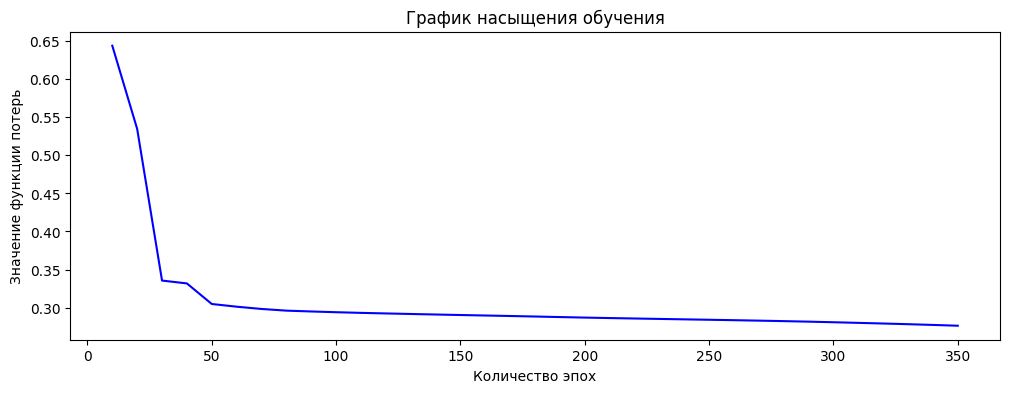

In [24]:
plt.figure(figsize=(12, 4))
plt.plot(epochs_plt, losses, label='График насыщения обучения', color='blue')
plt.title('График насыщения обучения')
plt.xlabel('Количество эпох')
plt.ylabel('Значение функции потерь')

In [21]:
# Оценка модели
model.eval()
with torch.no_grad():
    y_pred_proba = model(X_test_tensor).numpy()
    y_pred_binary = (y_pred_proba > 0.5).astype(int)

# Метрики
roc_auc = roc_auc_score(y_test, y_pred_proba)
mae = mean_absolute_error(y_test, y_pred_proba)

print(f'ROC-AUC: {roc_auc:.4f}')
print(f'MAE: {mae:.4f}')

with torch.no_grad():
    train_proba = torch.sigmoid(model(X_train_tensor)).numpy().flatten()
train_auc = roc_auc_score(y_train, train_proba)
print(f"\nROC-AUC на тренировочных данных: {train_auc:.4f}")
diff = train_auc-roc_auc
print(f"\nDifference:  {diff:.4f}")

ROC-AUC: 0.7151
MAE: 0.1598

ROC-AUC на тренировочных данных: 0.7531

Difference:  0.0380


In [22]:
def mean_absolute_percentage_error(y_true, y_pred):
    """Calculate MAPE for binary classification probabilities"""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    
    # Avoid division by zero
    mask = y_true != 0
    if np.sum(mask) == 0:
        return np.inf
    
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

In [23]:
# Дополнительные метрики
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
# Оценка модели с дополнительными метриками
model.eval()
with torch.no_grad():
    y_pred_proba = model(X_test_tensor).numpy()
    y_pred_binary = (y_pred_proba > 0.5).astype(int)

# Метрики
roc_auc = roc_auc_score(y_test, y_pred_proba)
mae = mean_absolute_error(y_test, y_pred_proba)
mape_score = mean_absolute_percentage_error(y_test, y_pred_proba)

accuracy = accuracy_score(y_test, y_pred_binary)
precision = precision_score(y_test, y_pred_binary)
recall = recall_score(y_test, y_pred_binary)
f1 = f1_score(y_test, y_pred_binary)

print(f'ROC-AUC: {roc_auc:.4f}')
print(f'MAE: {mae:.4f}')
print(f'MAPE: {mape_score:.4f}%')
print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1-Score: {f1:.4f}')

# Матрица ошибок
cm = confusion_matrix(y_test, y_pred_binary)
print(f'Confusion Matrix:\n{cm}')
with torch.no_grad():
    train_proba = torch.sigmoid(model(X_train_tensor)).numpy().flatten()
train_auc = roc_auc_score(y_train, train_proba)
print(f"\nROC-AUC на тренировочных данных: {train_auc:.4f}")
diff = train_auc-roc_auc
print(f"\nDifference:  {diff:.4f}")

ROC-AUC: 0.7151
MAE: 0.1598
MAPE: 84.5180%
Accuracy: 0.9040
Precision: 0.5143
Recall: 0.0266
F1-Score: 0.0506
Confusion Matrix:
[[19030    51]
 [ 1976    54]]

ROC-AUC на тренировочных данных: 0.7531

Difference:  0.0380
